Training Model 1 (Linear)...
Model 1 Accuracy: 52.00% | Final Cost: 0.6930

Training Model 2 (Polynomial)...
Model 2 Accuracy: 50.00% | Final Cost: 2.7266


C:\Users\ASUS TUF GAMING A15\AppData\Local\Temp\ipykernel_24388\1999875855.py:105: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs_grid, levels=[0.5], colors='black', linewidths=2, label='Poly Boundary')


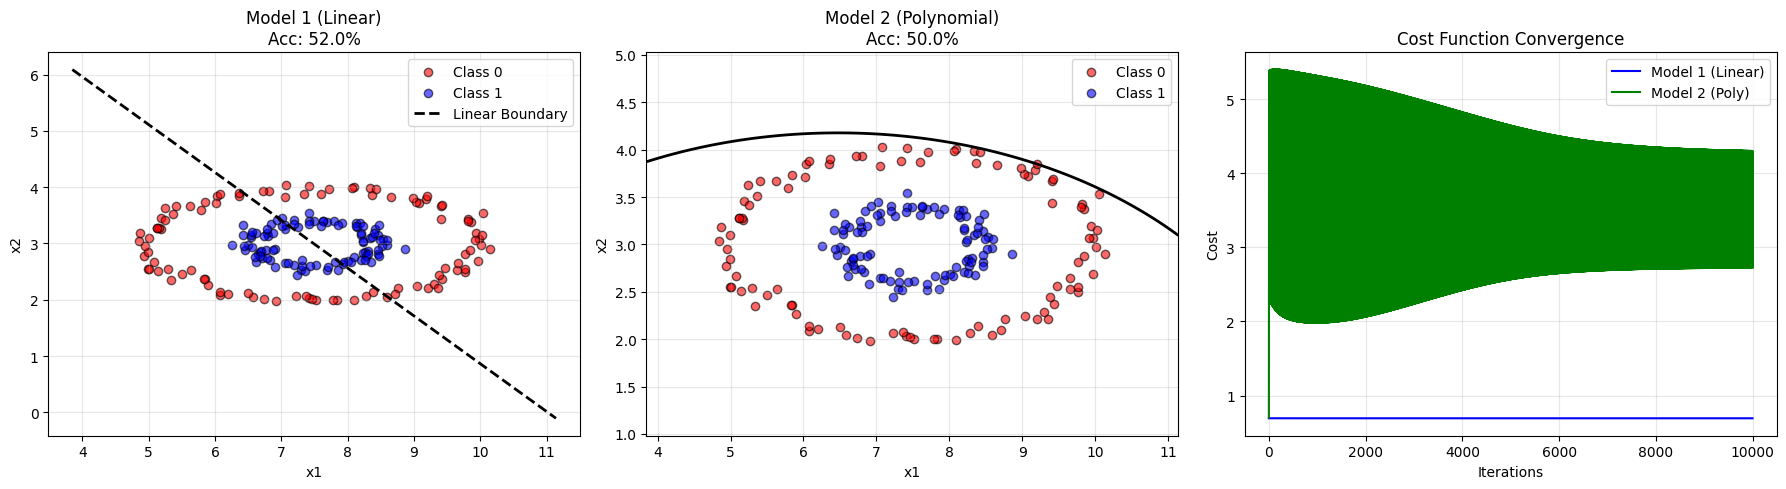


COMPARISON RESULT
✅ Model 1 (Linear) is sufficient (or Model 2 overfit).
   Difference: 2.00%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. LOAD AND PREPARE DATA
# ============================================
df = pd.read_csv('data_3_1_2.csv')
X_raw = df[['x1', 'x2']].values
y = df['class'].values  # 1D array
m = len(y)

# --- Feature Engineering for Model 2 (Polynomial) ---
# Create polynomial features: [x1, x2, x1^2, x2^2]
X_poly = np.c_[X_raw, X_raw[:, 0]**2, X_raw[:, 1]**2]

# Add bias term (x0 = 1)
X_b_linear = np.c_[np.ones((m, 1)), X_raw]       # Shape: (m, 3) for h1
X_b_poly   = np.c_[np.ones((m, 1)), X_poly]      # Shape: (m, 5) for h2

# ============================================
# 2. CORE FUNCTIONS (From Scratch)
# ============================================
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_cost(X, y, theta):
    h = sigmoid(X @ theta)
    epsilon = 1e-5
    cost = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

def gradient_descent(X, y, theta, lr, iters):
    y_col = y.reshape(-1, 1)
    costs = []
    for i in range(iters):
        h = sigmoid(X @ theta)
        grad = (1/m) * (X.T @ (h - y_col))
        theta = theta - lr * grad
        costs.append(compute_cost(X, y_col, theta))
    return theta, costs

def predict(X, theta):
    probs = sigmoid(X @ theta)
    return (probs >= 0.5).astype(int).flatten()

# ============================================
# 3. TRAIN MODEL 1: LINEAR (h1)
# ============================================
print("Training Model 1 (Linear)...")
theta1 = np.zeros((3, 1))
lr1, iters1 = 0.1, 10000
theta1_opt, costs1 = gradient_descent(X_b_linear, y, theta1, lr1, iters1)

y_pred1 = predict(X_b_linear, theta1_opt)
acc1 = np.mean(y_pred1 == y) * 100
print(f"Model 1 Accuracy: {acc1:.2f}% | Final Cost: {costs1[-1]:.4f}")

# ============================================
# 4. TRAIN MODEL 2: POLYNOMIAL (h2)
# ============================================
print("\nTraining Model 2 (Polynomial)...")
theta2 = np.zeros((5, 1))
# Note: Polynomial features might need a lower learning rate or scaling, 
# but we will try standard GD first. If it diverges, reduce lr.
lr2, iters2 = 0.01, 10000 
theta2_opt, costs2 = gradient_descent(X_b_poly, y, theta2, lr2, iters2)

y_pred2 = predict(X_b_poly, theta2_opt)
acc2 = np.mean(y_pred2 == y) * 100
print(f"Model 2 Accuracy: {acc2:.2f}% | Final Cost: {costs2[-1]:.4f}")

# ============================================
# 5. VISUALIZATION & COMPARISON
# ============================================
plt.figure(figsize=(18, 5))

# --- Plot A: Model 1 Decision Boundary ---
plt.subplot(1, 3, 1)
plt.scatter(X_raw[y==0][:, 0], X_raw[y==0][:, 1], c='red', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_raw[y==1][:, 0], X_raw[y==1][:, 1], c='blue', label='Class 1', alpha=0.6, edgecolors='k')

# Linear Boundary: θ0 + θ1*x1 + θ2*x2 = 0 => x2 = -(θ0 + θ1*x1)/θ2
x1_vals = np.array([X_raw[:, 0].min()-1, X_raw[:, 0].max()+1])
x2_vals = -(theta1_opt[0] + theta1_opt[1]*x1_vals) / theta1_opt[2]
plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label='Linear Boundary')
plt.title(f'Model 1 (Linear)\nAcc: {acc1:.1f}%')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(alpha=0.3)

# --- Plot B: Model 2 Decision Boundary ---
plt.subplot(1, 3, 2)
plt.scatter(X_raw[y==0][:, 0], X_raw[y==0][:, 1], c='red', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_raw[y==1][:, 0], X_raw[y==1][:, 1], c='blue', label='Class 1', alpha=0.6, edgecolors='k')

# Polynomial Boundary: θ0 + θ1*x1 + θ2*x2 + θ3*x1^2 + θ4*x2^2 = 0
# We plot this by creating a mesh grid and finding the contour where probability = 0.5
xx, yy = np.meshgrid(np.linspace(X_raw[:, 0].min()-1, X_raw[:, 0].max()+1, 200),
                     np.linspace(X_raw[:, 1].min()-1, X_raw[:, 1].max()+1, 200))
# Construct polynomial features for the grid
grid_poly = np.c_[np.ones((xx.ravel().shape[0], 1)), 
                  xx.ravel(), yy.ravel(), 
                  xx.ravel()**2, yy.ravel()**2]
probs_grid = sigmoid(grid_poly @ theta2_opt).reshape(xx.shape)

plt.contour(xx, yy, probs_grid, levels=[0.5], colors='black', linewidths=2, label='Poly Boundary')
plt.title(f'Model 2 (Polynomial)\nAcc: {acc2:.1f}%')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(alpha=0.3)

# --- Plot C: Cost Convergence Comparison ---
plt.subplot(1, 3, 3)
plt.plot(costs1, label='Model 1 (Linear)', color='blue')
plt.plot(costs2, label='Model 2 (Poly)', color='green')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('problem2_comparison.png', dpi=300)
plt.show()

# ============================================
# 6. FINAL CONCLUSION
# ============================================
print("\n" + "="*40)
print("COMPARISON RESULT")
print("="*40)
if acc2 > acc1:
    print(f"✅ Model 2 (Polynomial) is BETTER.")
    print(f"   Improvement: {acc2 - acc1:.2f}%")
    print("   Reason: The data is likely not linearly separable. The quadratic terms allow")
    print("   the decision boundary to curve, fitting the circular/elliptical pattern better.")
else:
    print(f"✅ Model 1 (Linear) is sufficient (or Model 2 overfit).")
    print(f"   Difference: {acc1 - acc2:.2f}%")
    
print("="*40)